# Analyse Pose Data

In [4]:
from mpl_toolkits.mplot3d import Axes3D
from camkit3d.pose3d import Pose3DProjector
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

# Set up notebook to display plots inline
%matplotlib inline

print("✓ Imports successful!")

✓ Imports successful!


## Setup file paths

In [17]:
from pathlib import Path

SESSION_DIR = Path("/Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing")
OUTPUT_3D_DIR      = SESSION_DIR / "data_3d"
VISUALIZATION_DIR  = SESSION_DIR / "visualizations"

# (Optional) create output dirs if missing
OUTPUT_3D_DIR.mkdir(parents=True, exist_ok=True)
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

print(f"Session:            {SESSION_DIR}")
print(f"3D output dir:      {OUTPUT_3D_DIR}")
print(f"Visualization dir:  {VISUALIZATION_DIR}")

# Create output directories
Path(OUTPUT_3D_DIR).mkdir(parents=True, exist_ok=True)
Path(VISUALIZATION_DIR).mkdir(parents=True, exist_ok=True)


Session:            /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing
3D output dir:      /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/data_3d
Visualization dir:  /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/visualizations


In [18]:
# Load the 3D points
points_3d = np.load(str(Path(OUTPUT_3D_DIR) / "pose_3d.npy"))

# Load the metadata
with open(Path(OUTPUT_3D_DIR) / "pose_3d.json") as f:
    metadata = json.load(f)

## Quick visualisation

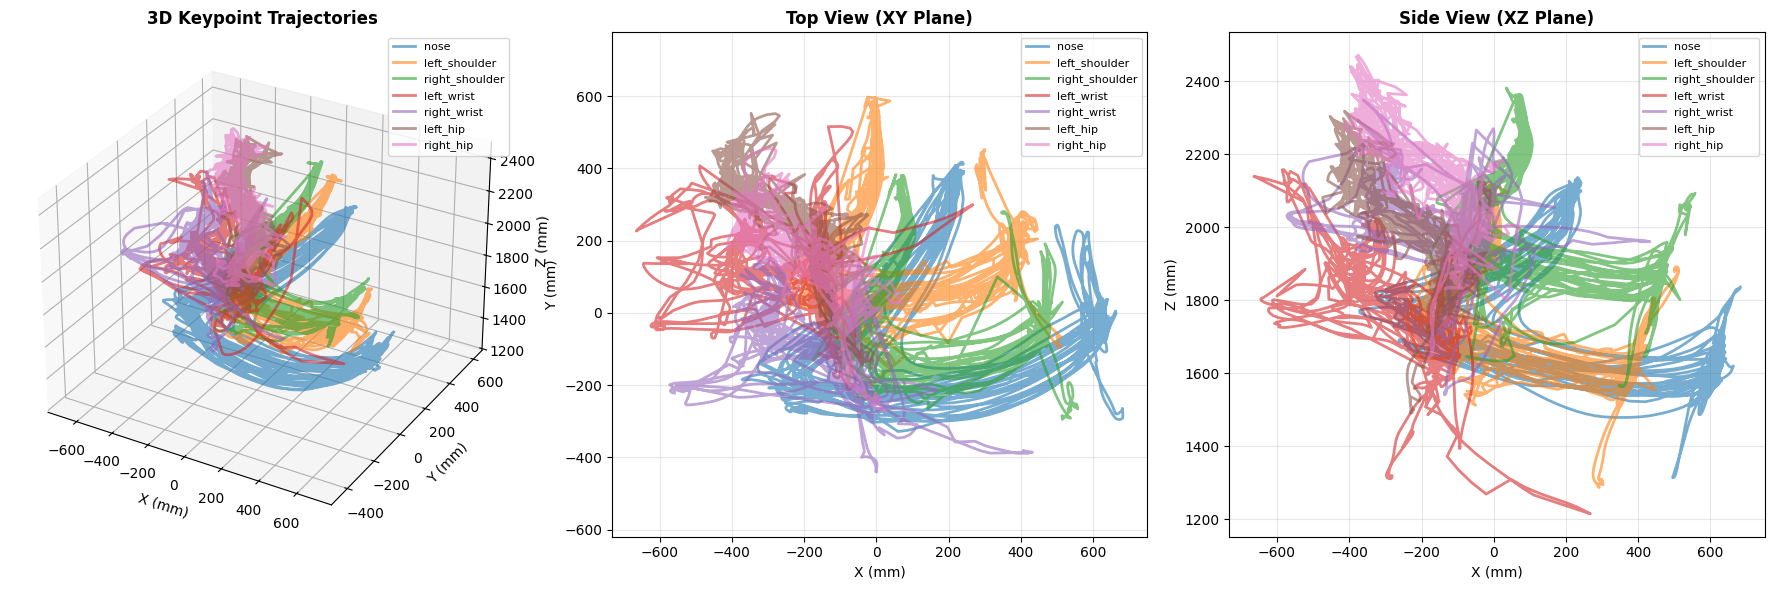

In [7]:
# Plot the 3D movement of key body points

# Select key keypoints to visualize (you can change these)
key_keypoints = {
    0: 'nose',
    11: 'left_shoulder',
    12: 'right_shoulder',
    15: 'left_wrist',
    16: 'right_wrist',
    23: 'left_hip',
    24: 'right_hip'
}

fig = plt.figure(figsize=(18, 6))

# Plot 1: 3D trajectory
ax1 = fig.add_subplot(131, projection='3d')

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax1.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('3D Keypoint Trajectories', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')

# Plot 2: Top view (XY plane)
ax2 = fig.add_subplot(132)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax2.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax2.set_xlabel('X (mm)', fontsize=10)
ax2.set_ylabel('Y (mm)', fontsize=10)
ax2.set_title('Top View (XY Plane)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)
ax2.axis('equal')

# Plot 3: Side view (XZ plane)
ax3 = fig.add_subplot(133)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax3.plot(
            trajectory[valid, 0],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax3.set_xlabel('X (mm)', fontsize=10)
ax3.set_ylabel('Z (mm)', fontsize=10)
ax3.set_title('Side View (XZ Plane)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

plt.tight_layout()
trajectory_plot_path = Path(VISUALIZATION_DIR) / "3d_trajectories.png"
# plt.savefig(trajectory_plot_path, dpi=150, bbox_inches='tight')
plt.show()




## Some very simple kinematic analysis

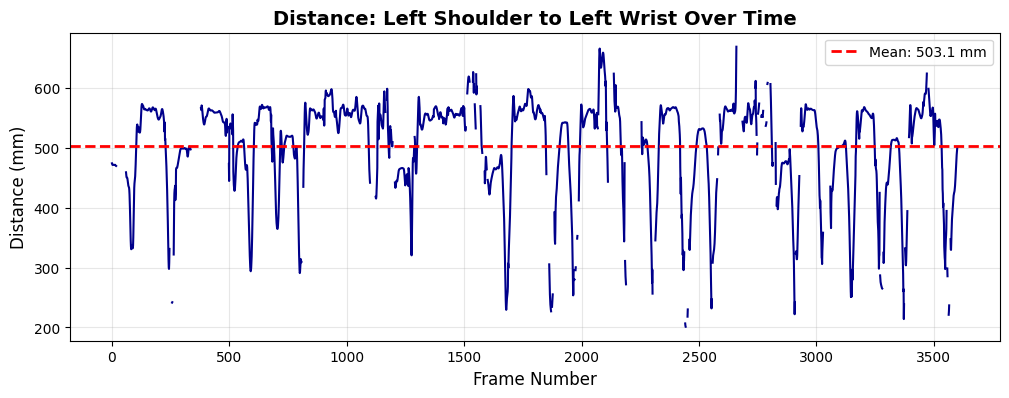

  Mean distance: 503.13 mm
  Std deviation: 81.19 mm


In [9]:
# Example: Calculate distance between two keypoints over time
from scipy.spatial.distance import euclidean

# Calculate distance from left shoulder to left wrist over all frames
left_shoulder_idx = 11
left_wrist_idx = 15

distances = []
for frame in range(points_3d.shape[0]):
    shoulder = points_3d[frame, left_shoulder_idx, :]
    wrist = points_3d[frame, left_wrist_idx, :]
    
    # Only calculate if both points are valid (not NaN)
    if not np.any(np.isnan(shoulder)) and not np.any(np.isnan(wrist)):
        dist = euclidean(shoulder, wrist)
        distances.append(dist)
    else:
        distances.append(np.nan)

distances = np.array(distances)

# Plot the distance over time
plt.figure(figsize=(12, 4))
plt.plot(distances, linewidth=1.5, color='darkblue')
plt.xlabel('Frame Number', fontsize=12)
plt.ylabel('Distance (mm)', fontsize=12)
plt.title('Distance: Left Shoulder to Left Wrist Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics
valid_distances = distances[~np.isnan(distances)]
plt.axhline(np.mean(valid_distances), color='red', linestyle='--', 
            label=f'Mean: {np.mean(valid_distances):.1f} mm', linewidth=2)
plt.legend()

distance_plot_path = Path(VISUALIZATION_DIR) / "shoulder_wrist_distance.png"
# plt.savefig(distance_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"  Mean distance: {np.mean(valid_distances):.2f} mm")
print(f"  Std deviation: {np.std(valid_distances):.2f} mm")


## Import the analysis tools

In [19]:
from camkit3d.analysis import (
    detect_person_orientation, 
    align_pose_to_standard_frame,
    plot_aligned_skeleton,
    animate_3d_pose,
    interpolate_nans
)

from camkit3d.viewer import viewer

%matplotlib qt

## Detect the person's orientation

`detect_person_orientation(points_3d)` derives a body-centred coordinate frame from
3D pose landmarks, so recordings can be re-expressed in upright, person-facing,
floor-referenced coordinates regardless of camera placement. It returns three
orthogonal anatomical axes (up, forward, right), a `rotation_matrix` mapping world →
anatomical frame, and the `ground_plane_z` floor position.

### Coordinate system
The anatomical frame is defined by the person's own body: **up** runs from the hip
midpoint to the shoulder midpoint (torso long axis), **forward** points out of the
chest toward where the nose faces, and **left/right** is the third dimensnion defined 
from the person's perspective. 

The floor sits at `ground_plane_z` along the up-axis, estimated as the 5th percentile of 
ankle heights (projected onto the up-axis) across sampled frames . Units remain in millimetres.

In [13]:
# Detect orientation (uses median across frames for robustness)
orientation = detect_person_orientation(points_3d)
# Realign
points_3d_aligned, R, orient = align_pose_to_standard_frame(points_3d)


DETECTING PERSON ORIENTATION

✓ UP direction detected: [0.925, -0.061, -0.375]
  Dominant axis: X
✓ FORWARD direction detected: [-0.280, -0.776, -0.566]
✓ RIGHT direction detected: [0.256, -0.628, 0.734]
✓ Ground plane detected at: -1606.15 mm along up-axis

✓ Orientation detection complete!

DETECTING PERSON ORIENTATION

✓ UP direction detected: [0.925, -0.061, -0.375]
  Dominant axis: X
✓ FORWARD direction detected: [-0.280, -0.776, -0.566]
✓ RIGHT direction detected: [0.256, -0.628, 0.734]
✓ Ground plane detected at: -1606.15 mm along up-axis

✓ Orientation detection complete!
Alignment check  UP->[ 0. -0.  1.]  FWD->[-0.  1. -0.]  RIGHT->[ 1. -0.  0.]


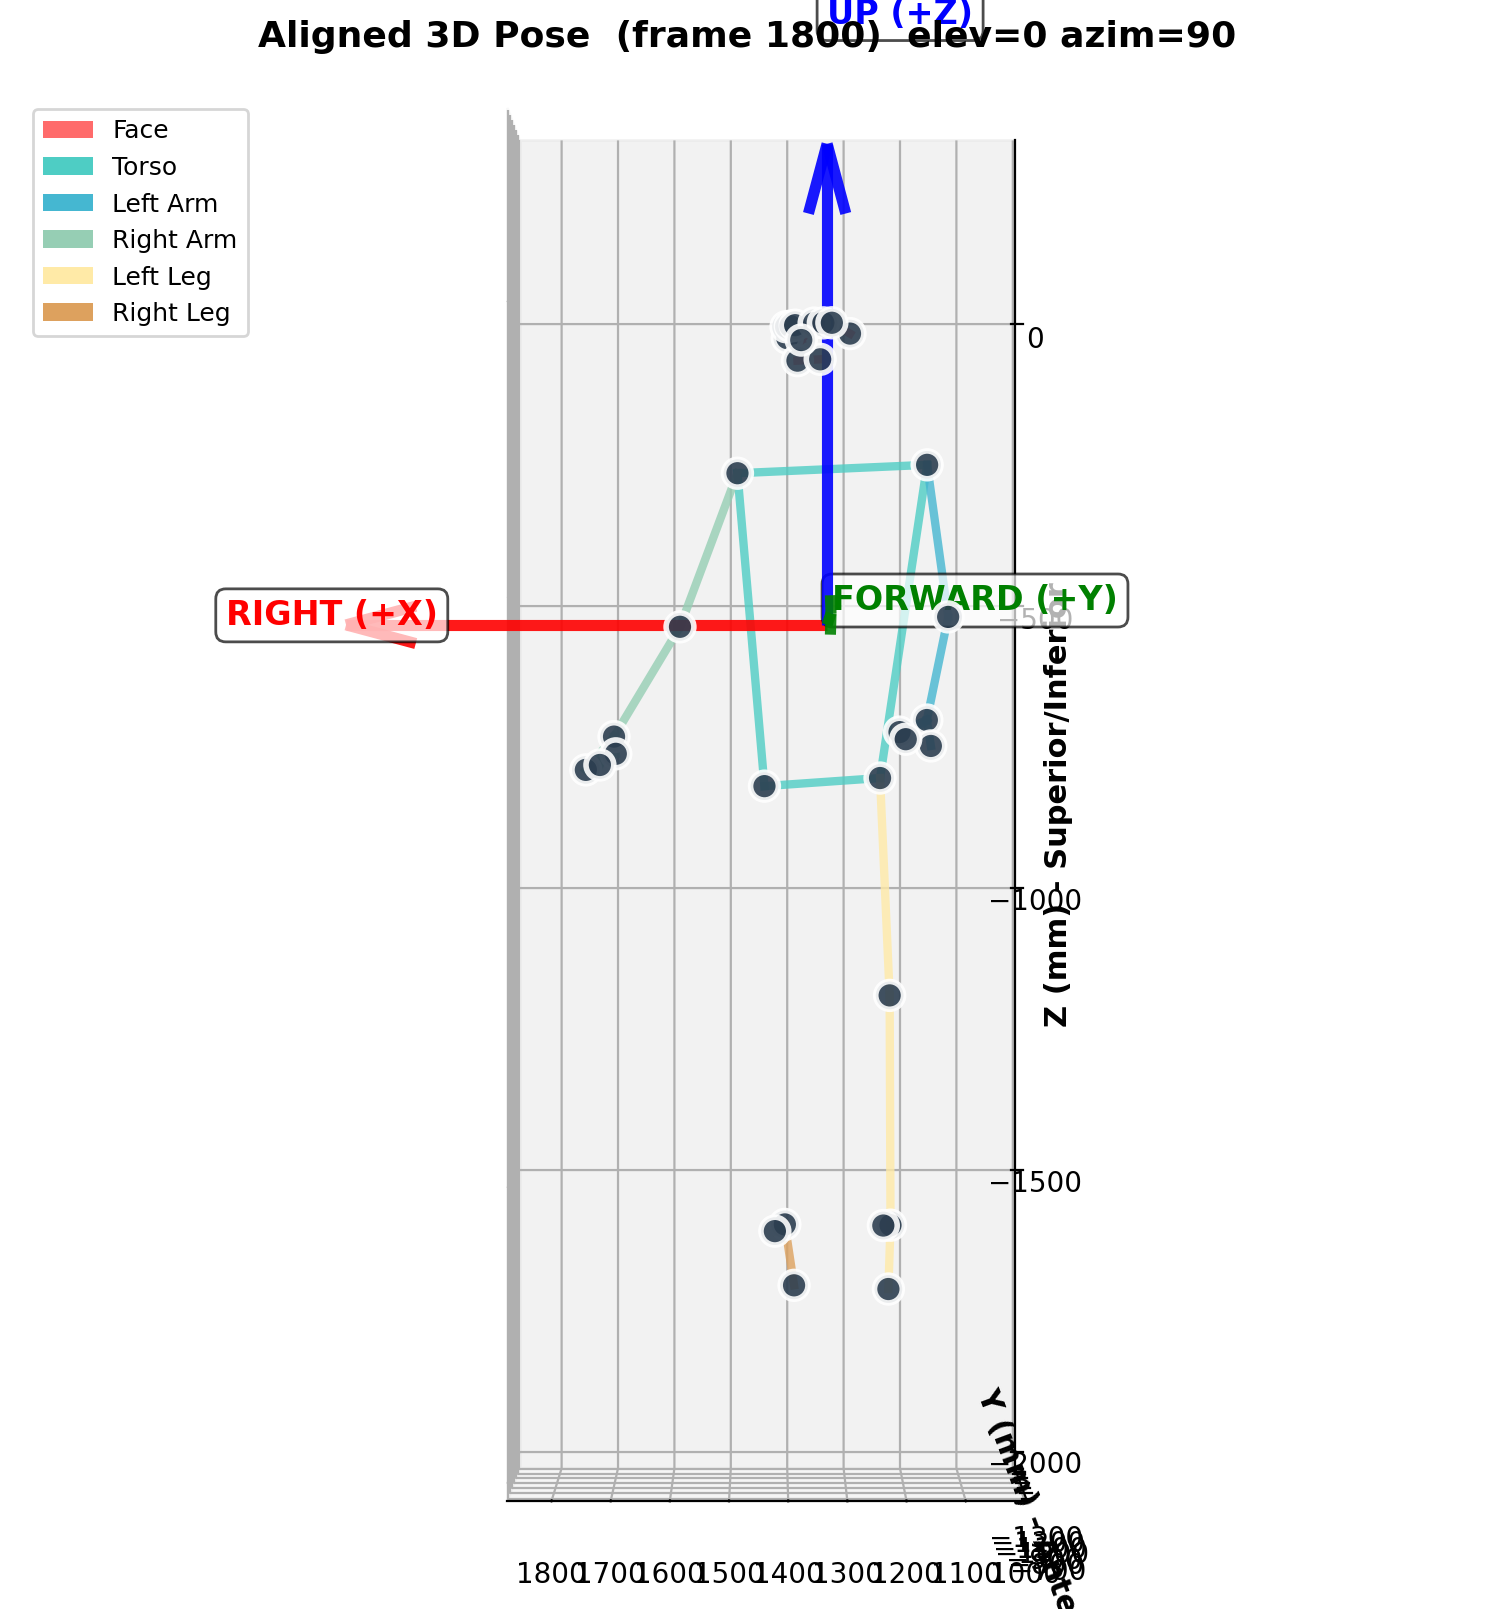

In [20]:
# 3. Static skeleton plot
%matplotlib qt
plot_aligned_skeleton(points_3d_aligned, elev=0, azim=90)

## Interpolate NaNs

See missing_data.md

#### Options you can tweak in `interpolate_nans(...)`

- **`method`**  
  Interpolation strategy:
  - `"pchip"` – Smooth, shape-preserving, no overshoot. Best default for mocap.
  - `"linear"` – Straight-line interpolation. Fast and safe, but creates visible
    kinks at gap boundaries.
  - `"savgol"` – Linear interpolation followed by Savitzky–Golay smoothing.
    Useful when surrounding data are noisy.

- **`max_gap_seconds`**  
  Maximum duration (in seconds) of a bounded NaN gap to fill.  
  Longer gaps are left as NaN.

- **`fps`**  
  Frame rate of the data. Used to convert `max_gap_seconds` into a frame count.

- **`savgol_window`** *(only for `method="savgol"`)*  
  Window length of the Savitzky–Golay filter (must be an odd integer).  
  Larger values give smoother results but may blur fast motion.

- **`savgol_polyorder`** *(only for `method="savgol"`)*  
  Polynomial order for the Savitzky–Golay filter.  
  Higher orders can follow curvature better but may fit noise.

- **`verbose`**  
  If `True`, prints a summary report of how many gaps and values were filled or
  skipped.


In [29]:
# PCHIP — best default, smooth & no overshoot
points_3d_filled, report = interpolate_nans(points_3d_aligned, method="pchip", max_gap_seconds=10.0, fps=30)


  INTERPOLATION REPORT  —  method: PCHIP
  max gap: 10.0s (300 frames @ 30 fps)
  Data shape        : (3601, 33, 3)
  Total values      :    356,499
  NaN before        :     48,741  ( 13.7%)
  Interpolated      :     48,552  ( 13.6%)
  NaN after         :        189  (  0.1%)
--------------------------------------------------------------
  Gaps found        :   6846
    Filled          :   6843
    Skipped (long)  :      0  (> 10.0s)
    Skipped (edge)  :      3  (leading/trailing/all-NaN)


In [30]:
left_shoulder_idx = 11
left_wrist_idx = 15

def wrist_shoulder_distance(points):
    """Compute shoulder->wrist distance per frame, NaN where either point is missing."""
    d = np.full(points.shape[0], np.nan)
    for frame in range(points.shape[0]):
        shoulder = points[frame, left_shoulder_idx, :]
        wrist = points[frame, left_wrist_idx, :]
        if not np.any(np.isnan(shoulder)) and not np.any(np.isnan(wrist)):
            d[frame] = euclidean(shoulder, wrist)
    return d

# Distances before and after interpolation
dist_original = wrist_shoulder_distance(points_3d_aligned)
dist_filled = wrist_shoulder_distance(points_3d_filled)

dist_original = wrist_shoulder_distance(points_3d_aligned)
dist_filled = wrist_shoulder_distance(points_3d_filled)

plt.figure(figsize=(12, 4))
plt.plot(dist_filled, color='red', linewidth=1.5, label='Filled')
plt.plot(dist_original, color='black', linewidth=1.5, label='Original')
plt.xlabel('Frame Number', fontsize=12)
plt.ylabel('Distance (mm)', fontsize=12)
plt.title('Left Shoulder to Left Wrist Distance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Data Viewer

In [32]:
viewer(points_3d_filled, fps=30)

Viewer saved: /var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/pose_viewer_5s4kc0xg.html


'/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/pose_viewer_5s4kc0xg.html'

## Animate the data and save to a real time video

In [20]:
# From the front
animate_3d_pose(
    points_3d_filled,
    show_floor=False,
    view_mode = 'custom',
    rotation_speed=0,
    output_path = OUTPUT_DIR / "animations" / "pose_front.mp4",
    elevation=20,
    azimuth_start=128,
    keypoint_size=70,
    line_width=4,
    show_axes=True,
    fps=30,
    quality='high'
)



CREATING 3D POSE ANIMATION

Settings:
  Frames: 3601/3601  FPS: 30  Duration: 120.03s
  View: custom  Quality: high (DPI: 150)
  Output: /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/pose_front.mp4

Generating animation frames...
Saving video to /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/pose_front.mp4...


Rendering:   0%|          | 0/3601 [00:00<?, ?it/s]INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1800x1198 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec libx264 -b 5000k -y /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/pose_front.mp4
Rendering: 100%|██████████| 3601/3601 [02:34<00:00, 23.24it/s]


✓ Animation saved! /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/pose_front.mp4 (49.70 MB, 120.03s)


'/Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/pose_front.mp4'

## Combine with the original videos

In [21]:
from pathlib import Path
import cv2
import numpy as np


def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap


def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h


def fit_with_letterbox(frame, target_w, target_h):
    """Resize preserving aspect ratio; pad with black to exactly (target_w, target_h)."""
    if frame is None:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    h, w = frame.shape[:2]
    if w == 0 or h == 0:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def combine_cameras_and_multiplot(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/multiplot.mp4",
    out_name="animations/video_pose.mp4",
):
    """
    Combine synchronized camera videos with multi-angle 3D pose visualization.

    Layout:
    ┌─────────────┬─────────────┐
    │   Camera 0  │             │
    ├─────────────┤   Multiplot │
    │   Camera 1  │   (2x2 3D)  │
    ├─────────────┤             │
    │   Camera 2  │             │
    └─────────────┴─────────────┘

    Left: 3 synchronized camera videos stacked vertically.
    Right: multi-angle 3D pose animation (multiplot.mp4).
    """
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    multiplot_path = OUTPUT_DIR / multiplot_rel
    out_path = OUTPUT_DIR / out_name

    # Validate inputs
    if not multiplot_path.exists():
        raise FileNotFoundError(f"Missing multiplot video: {multiplot_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(f"Missing synchronized videos folder: {synced_dir}")

    camera_paths = sorted(synced_dir.glob("camera_*_synchronized.mp4"))[:3]
    if len(camera_paths) < 3:
        raise FileNotFoundError(
            f"Need at least 3 camera videos in {synced_dir}, found {len(camera_paths)}"
        )

    print("=" * 70)
    print("COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION")
    print("=" * 70)

    cap_multiplot = open_or_raise(multiplot_path)
    caps_cameras = [open_or_raise(p) for p in camera_paths]

    fps_multi, n_multi, multi_w, multi_h = get_video_info(cap_multiplot)
    camera_infos = [get_video_info(c) for c in caps_cameras]

    out_fps = fps_multi if fps_multi and fps_multi > 0 else 30.0

    print(f"\nVideo information:")
    print(f"  Multiplot: {multi_w}x{multi_h} @ {fps_multi:.2f} fps, {n_multi} frames")
    for i, (fps, n, w, h) in enumerate(camera_infos):
        print(f"  Camera {i}: {w}x{h} @ {fps:.2f} fps, {n} frames")

    min_frames = min(n_multi, *[info[1] for info in camera_infos])
    if min_frames <= 0:
        raise RuntimeError("Could not determine valid frame counts (min_frames <= 0).")

    # ------------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------------
    # Left column: same height as multiplot, split into 3 equal camera cells.
    # Width is chosen to preserve the aspect ratio of the source cameras so
    # the letterboxing has minimal black bars.
    cam_w, cam_h = camera_infos[0][2], camera_infos[0][3]
    camera_cell_h = multi_h // 3
    # Pick left_w from camera aspect, capped at multi_w to keep output sane
    if cam_h > 0:
        left_w = min(multi_w, int(round(camera_cell_h * cam_w / cam_h)))
    else:
        left_w = multi_w
    left_h = camera_cell_h * 3  # exact, avoids off-by-one from integer division

    right_w, right_h = multi_w, multi_h
    out_w = left_w + right_w
    out_h = max(left_h, right_h)

    print(f"\nOutput settings:")
    print(f"  Synchronized frames: {min_frames}")
    print(f"  Duration: {min_frames / out_fps:.2f} seconds")
    print(f"  FPS: {out_fps:.2f}")
    print(f"  Layout:")
    print(f"    Left (cameras):    {left_w}x{left_h} (3 cameras stacked, cell {left_w}x{camera_cell_h})")
    print(f"    Right (multiplot): {right_w}x{right_h}")
    print(f"    Output size:       {out_w}x{out_h}")

    # ------------------------------------------------------------------
    # Writer
    # ------------------------------------------------------------------
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")

    print(f"\nWriting combined video to {out_path} ...")

    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")

        # Multiplot (right)
        ok_multi, f_multi = cap_multiplot.read()
        if not ok_multi or f_multi is None:
            f_multi = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        elif f_multi.shape[:2] != (right_h, right_w):
            f_multi = cv2.resize(f_multi, (right_w, right_h), interpolation=cv2.INTER_AREA)

        # Cameras (left)
        camera_frames = []
        for cap in caps_cameras:
            ok, f = cap.read()
            if not ok:
                f = None
            camera_frames.append(fit_with_letterbox(f, left_w, camera_cell_h))

        left_side = np.vstack(camera_frames)

        # Pad/crop left column to match output height
        if left_side.shape[0] != out_h:
            if left_side.shape[0] < out_h:
                pad = np.zeros((out_h - left_side.shape[0], left_w, 3), dtype=np.uint8)
                left_side = np.vstack([left_side, pad])
            else:
                left_side = left_side[:out_h]

        # Pad multiplot to match output height too (in case left is taller)
        if f_multi.shape[0] != out_h:
            if f_multi.shape[0] < out_h:
                pad = np.zeros((out_h - f_multi.shape[0], right_w, 3), dtype=np.uint8)
                f_multi = np.vstack([f_multi, pad])
            else:
                f_multi = f_multi[:out_h]

        frame_out = np.hstack([left_side, f_multi])
        writer.write(frame_out)

    writer.release()
    cap_multiplot.release()
    for c in caps_cameras:
        c.release()

    print(f"\n✅ Combined video saved: {out_path}")
    print(f"  Size:     {out_w}x{out_h}")
    print(f"  Frames:   {min_frames}")
    print(f"  Duration: {min_frames / out_fps:.2f}s")

    return str(out_path)

In [22]:

result = combine_cameras_and_multiplot(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/pose_front.mp4",
    out_name="animations/video_pose.mp4"
)



COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION

Video information:
  Multiplot: 1800x1198 @ 30.00 fps, 3601 frames
  Camera 0: 1280x720 @ 30.00 fps, 3601 frames
  Camera 1: 1280x720 @ 30.00 fps, 3601 frames
  Camera 2: 1280x720 @ 30.00 fps, 3601 frames

Output settings:
  Synchronized frames: 3601
  Duration: 120.03 seconds
  FPS: 30.00
  Layout:
    Left (cameras):    709x1197 (3 cameras stacked, cell 709x399)
    Right (multiplot): 1800x1198
    Output size:       2509x1198

Writing combined video to /Users/robertseymour/Documents/recordings/2026-05-20_14-58-50_rob_standing/animations/video_pose.mp4 ...
  Processing frame 0/3601...
  Processing frame 100/3601...
  Processing frame 200/3601...
  Processing frame 300/3601...
  Processing frame 400/3601...
  Processing frame 500/3601...
  Processing frame 600/3601...
  Processing frame 700/3601...
  Processing frame 800/3601...
  Processing frame 900/3601...
  Processing frame 1000/3601...
  Processing frame 1100/3601...
  Process

## Combine this video with the labelled videos!

In [23]:
from pathlib import Path
import math
import cv2
import numpy as np


def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap


def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h


def resize_to_width(frame, target_w):
    """Resize to target_w preserving aspect ratio (no padding/cropping)."""
    if frame is None:
        return None
    h, w = frame.shape[:2]
    if w <= 0 or h <= 0:
        return None
    scale = target_w / w
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(frame, (target_w, new_h), interpolation=cv2.INTER_AREA)


def compute_grid_dims(n: int) -> tuple[int, int]:
    """
    Return (n_cols, n_rows) for a grid that sensibly fits n videos.

    Strategy: favour landscape grids (cols >= rows).
    - 1  → 1x1
    - 2  → 2x1
    - 3  → 3x1  (side-by-side strip; swap to 2x2 with blank if you prefer)
    - 4  → 2x2
    - 5  → 3x2  (last row has 2 centred cells)
    - 6  → 3x2
    - 7  → 4x2
    - 8  → 4x2
    - 9  → 3x3
    - …  → ceil(sqrt(n)) cols, ceil(n/cols) rows
    """
    if n <= 0:
        raise ValueError("n must be >= 1")
    n_cols = math.ceil(math.sqrt(n))
    n_rows = math.ceil(n / n_cols)
    return n_cols, n_rows


def build_grid_frame(
    cam_frames: list,
    infos: list,
    n_cols: int,
    n_rows: int,
    grid_w: int,
    grid_h: int,
) -> np.ndarray:
    """
    Arrange cam_frames into an (grid_w x grid_h) mosaic.

    Each cell is sized (cell_w x cell_h).  Frames are fitted inside their cell
    with aspect-ratio preservation (letterbox / pillarbox with black fill only
    at the cell level – the overall grid has no extra padding).
    The last row is centred if it is not full.
    """
    n = len(cam_frames)
    cell_w = grid_w // n_cols
    cell_h = grid_h // n_rows

    canvas = np.zeros((grid_h, grid_w, 3), dtype=np.uint8)

    for idx in range(n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols

        # Centre the last (potentially partial) row
        last_row_count = n - (n_rows - 1) * n_cols
        if row == n_rows - 1 and last_row_count < n_cols:
            # shift right so the occupied cells are centred
            col_offset = (n_cols - last_row_count) * cell_w // 2
        else:
            col_offset = 0

        x0 = col * cell_w + col_offset
        y0 = row * cell_h

        if idx >= n or cam_frames[idx] is None:
            # Empty cell – leave black
            continue

        frame = cam_frames[idx]
        fh, fw = frame.shape[:2]

        # Fit frame into cell while preserving aspect ratio
        scale = min(cell_w / fw, cell_h / fh)
        new_fw = max(1, int(round(fw * scale)))
        new_fh = max(1, int(round(fh * scale)))
        resized = cv2.resize(frame, (new_fw, new_fh), interpolation=cv2.INTER_AREA)

        # Centre within cell
        pad_x = (cell_w - new_fw) // 2
        pad_y = (cell_h - new_fh) // 2

        y1 = y0 + pad_y
        x1 = x0 + pad_x
        # Guard against off-canvas writes
        y2 = min(y1 + new_fh, grid_h)
        x2 = min(x1 + new_fw, grid_w)
        canvas[y1:y2, x1:x2] = resized[: y2 - y1, : x2 - x1]

    return canvas


def combine_cameras_and_front_view(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose.mp4",
    camera_glob="camera_*_synchronized_labeled.mp4",
    grid_target_h: int = 1080,
    front_view_width_ratio: float = 0.35,
):
    """
    Combine any number of synchronized camera videos (auto grid) with a front
    view 3D pose visualization.

    LAYOUT:
    - Left:  N camera videos arranged in an auto-sized grid that fills the
             left panel without borders.  The grid dimensions are chosen to be
             roughly square (cols >= rows).  If the last row is not full, those
             cells are horizontally centred.
    - Right: front-view video resized to match the full left-grid height
             (aspect-ratio preserved).
    - Output: [camera grid | front view]

    Args:
        OUTPUT_DIR:            Base output directory.
        synced_folder_name:    Folder (relative to OUTPUT_DIR) containing the
                               synchronized camera videos.
        front_view_rel:        Path to pose_front.mp4 relative to OUTPUT_DIR.
        out_name:              Output filename relative to OUTPUT_DIR.
        camera_glob:           Glob pattern to find labelled synchronized
                               camera videos inside synced_folder_name.
        grid_target_h:         Target height (px) for the camera grid.  Width
                               is derived from the source videos' aspect ratios.
        front_view_width_ratio: Approximate fraction of total output width
                               reserved for the front view (used only when the
                               front view's natural size is very different from
                               the grid; the grid height is always the master).

    Returns:
        str: Path to saved combined video.
    """
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    front_view_path = OUTPUT_DIR / front_view_rel
    out_path = OUTPUT_DIR / out_name

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    if not front_view_path.exists():
        raise FileNotFoundError(f"Missing front view video: {front_view_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(
            f"Missing synchronized videos folder: {synced_dir}"
        )

    camera_paths = sorted(synced_dir.glob(camera_glob))
    n_cams = len(camera_paths)
    if n_cams == 0:
        raise FileNotFoundError(
            f"No camera videos found in {synced_dir} matching '{camera_glob}'"
        )

    print("=" * 70)
    print(f"COMBINING {n_cams}-CAMERA GRID + FRONT VIEW 3D VISUALIZATION")
    print("=" * 70)

    # ------------------------------------------------------------------
    # Open captures & collect info
    # ------------------------------------------------------------------
    cap_front = open_or_raise(front_view_path)
    caps = [open_or_raise(p) for p in camera_paths]

    fps_front, n_front, front_w, front_h = get_video_info(cap_front)
    infos = [get_video_info(c) for c in caps]

    out_fps = fps_front if fps_front and fps_front > 0 else 30.0

    print("\nVideo information:")
    print(
        f"  Front view : {front_w}x{front_h} @ {fps_front:.2f} fps,"
        f" {n_front} frames"
    )
    for i, (fps, n, w, h) in enumerate(infos):
        print(
            f"  Camera {i:>2}  : {w}x{h} @ {fps:.2f} fps, {n} frames"
            f"   ({camera_paths[i].name})"
        )

    # ------------------------------------------------------------------
    # Sync: use the shortest video across all inputs
    # ------------------------------------------------------------------
    min_frames = min(n_front, *[info[1] for info in infos])
    if min_frames <= 0:
        raise RuntimeError(
            "Could not determine valid frame counts (min_frames <= 0)."
        )

    print("\nOutput settings:")
    print(f"  Synchronized frames : {min_frames}")
    print(f"  Duration            : {min_frames / out_fps:.2f} seconds")
    print(f"  FPS                 : {out_fps:.2f}")

    # ------------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------------
    n_cols, n_rows = compute_grid_dims(n_cams)
    print(f"\nGrid layout: {n_cams} cameras → {n_cols} cols × {n_rows} rows")

    # Derive a sensible cell size from the median source resolution
    src_ws = [info[2] for info in infos]
    src_hs = [info[3] for info in infos]
    median_w = sorted(src_ws)[len(src_ws) // 2]
    median_h = sorted(src_hs)[len(src_hs) // 2]

    # Cell size: fit median source into (grid_target_h / n_rows) tall cell
    cell_h = max(1, grid_target_h // n_rows)
    cell_w = max(1, int(round(median_w * (cell_h / median_h))))

    grid_w = cell_w * n_cols
    grid_h = cell_h * n_rows  # may differ slightly from grid_target_h

    # Front view: height matches grid, width preserves aspect ratio
    right_h = grid_h
    right_w = max(1, int(round(front_w * (right_h / front_h))))

    out_w = grid_w + right_w
    out_h = grid_h

    print("\nLayout:")
    print(f"  Cell size       : {cell_w}x{cell_h}")
    print(f"  Grid size       : {grid_w}x{grid_h}")
    print(f"  Front view size : {right_w}x{right_h}")
    print(f"  Output size     : {out_w}x{out_h}")

    # ------------------------------------------------------------------
    # Writer
    # ------------------------------------------------------------------
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")

    print("\nWriting combined video...")

    # ------------------------------------------------------------------
    # Frame loop
    # ------------------------------------------------------------------
    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")

        # Read camera frames
        cam_frames = []
        for cap in caps:
            ok, f = cap.read()
            cam_frames.append(f if ok and f is not None else None)

        # Build camera grid
        grid_left = build_grid_frame(
            cam_frames, infos, n_cols, n_rows, grid_w, grid_h
        )

        # Front view frame
        ok_front, f_front = cap_front.read()
        if not ok_front or f_front is None:
            f_front = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        else:
            f_front = cv2.resize(
                f_front, (right_w, right_h), interpolation=cv2.INTER_AREA
            )

        frame_out = np.hstack([grid_left, f_front])
        writer.write(frame_out)

    # ------------------------------------------------------------------
    # Cleanup
    # ------------------------------------------------------------------
    writer.release()
    cap_front.release()
    for c in caps:
        c.release()

    print("\n✅ Combined video saved successfully!")
    print(f"  Output   : {out_path}")
    print(f"  Size     : {out_w}x{out_h}")
    print(f"  Frames   : {min_frames}")
    print(f"  Duration : {min_frames / out_fps:.2f}s")

    return str(out_path)


# Example call:
result = combine_cameras_and_front_view(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="mediapipe_output/labeled_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose2.mp4",
)
print("Saved:", result)

COMBINING 3-CAMERA GRID + FRONT VIEW 3D VISUALIZATION

Video information:
  Front view : 1800x1198 @ 30.00 fps, 3601 frames
  Camera  0  : 1280x720 @ 30.00 fps, 3601 frames   (camera_0_synchronized_labeled.mp4)
  Camera  1  : 1280x720 @ 30.00 fps, 3601 frames   (camera_1_synchronized_labeled.mp4)
  Camera  2  : 1280x720 @ 30.00 fps, 3601 frames   (camera_2_synchronized_labeled.mp4)

Output settings:
  Synchronized frames : 3601
  Duration            : 120.03 seconds
  FPS                 : 30.00

Grid layout: 3 cameras → 2 cols × 2 rows

Layout:
  Cell size       : 960x540
  Grid size       : 1920x1080
  Front view size : 1623x1080
  Output size     : 3543x1080

Writing combined video...
  Processing frame 0/3601...
  Processing frame 100/3601...
  Processing frame 200/3601...
  Processing frame 300/3601...
  Processing frame 400/3601...
  Processing frame 500/3601...
  Processing frame 600/3601...
  Processing frame 700/3601...
  Processing frame 800/3601...
  Processing frame 900/360